# Feature Engineering y Experimentos A/B (Baseline, FE, FE + Tuning)

## Importar librerias y rutas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import time

warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, f1_score, roc_curve, auc,
                           average_precision_score, precision_recall_curve,
                           confusion_matrix)

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

# CONFIGURACIÓN DE RUTAS
BASE_DIR = "/workspaces/proyecto-zona-interes-Au"
OUTPUT_DIR = f"{BASE_DIR}/notebooks/outputs_sprint2"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuración cargada")
print(f"Base Directory: {BASE_DIR}")
print(f"Output Directory: {OUTPUT_DIR}")

Configuración cargada
Base Directory: /workspaces/proyecto-zona-interes-Au
Output Directory: /workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint2


## Feature Engineering

In [2]:
def crear_features_geoquimicos(df: pd.DataFrame) -> pd.DataFrame:
    """Función principal de Feature Engineering"""
    print("Iniciando Feature Engineering...")
    df_fe = df.copy()
    
    ratios = {
        'Au_Cu_ratio': ('Au_ppm', 'Cu_ppm'),
        'Au_Ag_ratio': ('Au_ppm', 'Ag_ppm'),
        'Au_As_ratio': ('Au_ppm', 'As_ppm'),
        'Au_Sb_ratio': ('Au_ppm', 'Sb_ppm'),
        'As_Sb_ratio': ('As_ppm', 'Sb_ppm'),
        'Cu_Ag_ratio': ('Cu_ppm', 'Ag_ppm'),
        'Pb_Zn_ratio': ('Pb_ppm', 'Zn_ppm'),
        'Bi_As_ratio': ('Bi_ppm', 'As_ppm'),
    }
    
    for name, (num, den) in ratios.items():
        if num in df_fe.columns and den in df_fe.columns:
            df_fe[name] = df_fe[num] / df_fe[den].replace(0, np.nan)
    
    pathfinders = ['As_ppm', 'Sb_ppm', 'Cu_ppm', 'Ag_ppm', 'Bi_ppm', 'Pb_ppm', 'Zn_ppm']
    available = [col for col in pathfinders if col in df_fe.columns]
    if available:
        df_fe['pathfinder_sum'] = df_fe[available].sum(axis=1)
        df_fe['pathfinder_mean'] = df_fe[available].mean(axis=1)
        df_fe['pathfinder_max'] = df_fe[available].max(axis=1)
    
    print(f"Feature Engineering completado: {df.shape[1]} → {df_fe.shape[1]} columnas")
    return df_fe

print("Funciones de Feature Engineering listas")

Funciones de Feature Engineering listas


## Cargar datos

In [3]:
ruta_train = f"{BASE_DIR}/data/interim/data_entrenamiento_balanceado.csv"
ruta_test = f"{BASE_DIR}/data/interim/data_prueba.csv"

df_train = pd.read_csv(ruta_train)
df_test = pd.read_csv(ruta_test)

print("Datos cargados correctamente:")
print(f"   Train balanceado → {df_train.shape}")
print(f"   Test            → {df_test.shape}")

Datos cargados correctamente:
   Train balanceado → (2994, 52)
   Test            → (427, 52)


## Aplicar Feature Engineering

In [4]:
df_train_fe = crear_features_geoquimicos(df_train)
df_test_fe = crear_features_geoquimicos(df_test)

df_train_fe.to_csv(f"{BASE_DIR}/data/interim/data_entrenamiento_balanceado_fe.csv", index=False)
df_test_fe.to_csv(f"{BASE_DIR}/data/interim/data_prueba_fe.csv", index=False)

print("Datos con Feature Engineering guardados correctamente")

Iniciando Feature Engineering...
Feature Engineering completado: 52 → 63 columnas
Iniciando Feature Engineering...
Feature Engineering completado: 52 → 63 columnas


Datos con Feature Engineering guardados correctamente


## Preparación de Feature

In [5]:
features_base = [col for col in df_train.columns if col not in ['target_Au', 'is_synthetic', 'Au_ppm', 'East', 'North', 'Level']]
features_fe = [col for col in df_train_fe.columns if col not in ['target_Au', 'is_synthetic', 'Au_ppm', 'East', 'North', 'Level']]

X_train_base = df_train[features_base]
X_test_base = df_test[features_base]
X_train_fe = df_train_fe[features_fe]
X_test_fe = df_test_fe[features_fe]

y_train = df_train['target_Au']
y_test = df_test['target_Au']

print(f"Features Base: {len(features_base)}")
print(f"Features con FE: {len(features_fe)}")

Features Base: 46
Features con FE: 57


## Experimentos A/B

In [6]:
resultados = []
all_tuning_results = []

# EXPERIMENTO 1: BASELINE
print(f"\nIniciando entrenamiento: BASELINE")
start = time.time()

model_base = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_base.fit(X_train_base, y_train)
y_pred_base = model_base.predict(X_test_base)
y_proba_base = model_base.predict_proba(X_test_base)[:, 1]

pr_base = average_precision_score(y_test, y_proba_base)
f1_base = f1_score(y_test, y_pred_base)
t1 = time.time() - start

print(f"{'='*90}")
print("EXPERIMENTO: BASELINE")
print(f"{'='*90}")
print(classification_report(y_test, y_pred_base))
print(f"PR-AUC: {pr_base:.4f} | F1-Score: {f1_base:.4f}")
print(f"Tiempo: {t1:.2f} segundos")

resultados.append({'Experimento': 'Baseline', 'PR_AUC': pr_base, 'F1_Score': f1_base, 'Tiempo(s)': round(t1,2)})

# EXPERIMENTO 2: BASELINE + FEATURE ENGINEERING
print(f"\nIniciando entrenamiento: BASELINE + FEATURE ENGINEERING")
start = time.time()

model_fe = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_fe.fit(X_train_fe, y_train)
y_pred_fe = model_fe.predict(X_test_fe)
y_proba_fe = model_fe.predict_proba(X_test_fe)[:, 1]

pr_fe = average_precision_score(y_test, y_proba_fe)
f1_fe = f1_score(y_test, y_pred_fe)
t2 = time.time() - start

print(f"{'='*90}")
print("EXPERIMENTO: BASELINE + FEATURE ENGINEERING")
print(f"{'='*90}")
print(classification_report(y_test, y_pred_fe))
print(f"PR-AUC: {pr_fe:.4f} | F1-Score: {f1_fe:.4f}")
print(f"Tiempo: {t2:.2f} segundos")

resultados.append({'Experimento': 'Baseline + FE', 'PR_AUC': pr_fe, 'F1_Score': f1_fe, 'Tiempo(s)': round(t2,2)})

# EXPERIMENTO 3: FEATURE ENGINEERING + TUNING
print(f"\nIniciando Experiment 3: FEATURE ENGINEERING + TUNING")
start_tuning = time.time()

param_grid = {
    'n_estimators': [60, 70, 80, 90, 100], 
    'max_depth': [11, 12, 13, 14, 15], 
    'min_samples_split': [2, 3, 4, 5, 6]
}

best_score = -1
best_params = None
best_model = None
best_time = 0

print("Evaluando combinaciones...\n")

for n_est in param_grid['n_estimators']:
    for depth in param_grid['max_depth']:
        for split in param_grid['min_samples_split']:
            params = {'n_estimators': n_est, 'max_depth': depth, 'min_samples_split': split}
            
            start_comb = time.time()
            
            model = RandomForestClassifier(random_state=42, class_weight='balanced', **params)
            model.fit(X_train_fe, y_train)
            y_pred = model.predict(X_test_fe)
            y_proba = model.predict_proba(X_test_fe)[:, 1]
            
            pr_auc = average_precision_score(y_test, y_proba)
            f1 = f1_score(y_test, y_pred)
            t_comb = time.time() - start_comb
            
            all_tuning_results.append({**params, 'PR_AUC': pr_auc, 'F1_Score': f1, 'Tiempo(s)': round(t_comb, 2)})
            
            if f1 > best_score:
                best_score = f1
                best_params = params
                best_model = model
                best_time = t_comb

t3_total = time.time() - start_tuning

# MEJOR COMBINACIÓN
y_pred_best = best_model.predict(X_test_fe)
y_proba_best = best_model.predict_proba(X_test_fe)[:, 1]
pr_best = average_precision_score(y_test, y_proba_best)
f1_best = f1_score(y_test, y_pred_best)

print(f"\n{'='*100}")
print("MEJOR COMBINACIÓN ENCONTRADA")
print("="*100)
print(f"Mejores parámetros: {best_params}")
print(classification_report(y_test, y_pred_best))
print(f"PR-AUC Mejor Modelo: {pr_best:.4f} | F1-Score Mejor Modelo: {f1_best:.4f}")
print(f"Tiempo Mejor Modelo: {best_time:.2f} segundos")
print(f"Tiempo total del Tuning: {t3_total:.2f} segundos")

resultados.append({'Experimento': 'FE + Tuning', 'PR_AUC': pr_best, 'F1_Score': f1_best, 'Tiempo(s)': round(best_time,2)})


Iniciando entrenamiento: BASELINE


EXPERIMENTO: BASELINE
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       375
           1       0.65      0.71      0.68        52

    accuracy                           0.92       427
   macro avg       0.80      0.83      0.82       427
weighted avg       0.92      0.92      0.92       427

PR-AUC: 0.7182 | F1-Score: 0.6789
Tiempo: 1.50 segundos

Iniciando entrenamiento: BASELINE + FEATURE ENGINEERING


EXPERIMENTO: BASELINE + FEATURE ENGINEERING
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       375
           1       0.98      0.79      0.87        52

    accuracy                           0.97       427
   macro avg       0.97      0.89      0.93       427
weighted avg       0.97      0.97      0.97       427

PR-AUC: 0.9792 | F1-Score: 0.8723
Tiempo: 0.89 segundos

Iniciando Experiment 3: FEATURE ENGINEERING + TUNING
Evaluando combinaciones...




MEJOR COMBINACIÓN ENCONTRADA
Mejores parámetros: {'n_estimators': 60, 'max_depth': 13, 'min_samples_split': 2}
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       375
           1       1.00      0.81      0.89        52

    accuracy                           0.98       427
   macro avg       0.99      0.90      0.94       427
weighted avg       0.98      0.98      0.98       427

PR-AUC Mejor Modelo: 0.9831 | F1-Score Mejor Modelo: 0.8936
Tiempo Mejor Modelo: 0.53 segundos
Tiempo total del Tuning: 93.36 segundos


## Comparacion Tuning


TABLA COMPARATIVA DE TODAS LAS COMBINACIONES DEL TUNING
     n_estimators  max_depth  min_samples_split  F1_Score  PR_AUC  Tiempo(s)
0              60         13                  2    0.8936  0.9831       0.53
1              70         11                  2    0.8866  0.9792       0.63
2              60         15                  2    0.8842  0.9817       0.68
3              60         11                  3    0.8817  0.9820       0.58
4              60         12                  3    0.8817  0.9800       0.55
..            ...        ...                ...       ...     ...        ...
120           100         11                  3    0.8444  0.9810       0.88
121           100         12                  4    0.8444  0.9799       0.93
122           100         13                  4    0.8444  0.9785       0.93
123           100         14                  4    0.8444  0.9755       0.89
124           100         15                  4    0.8444  0.9762       0.90

[125 rows x 6 colu

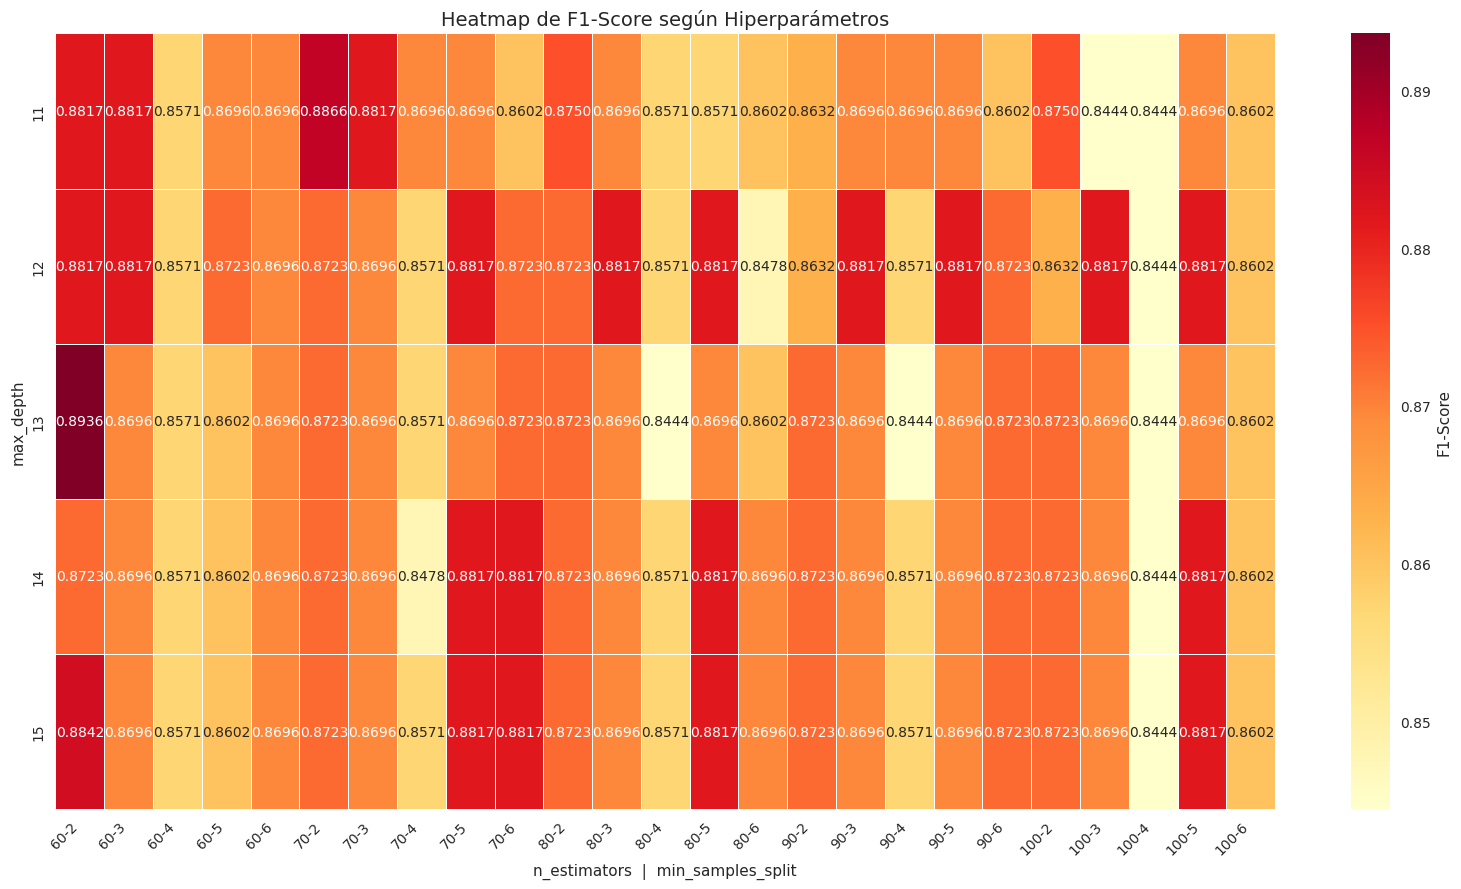

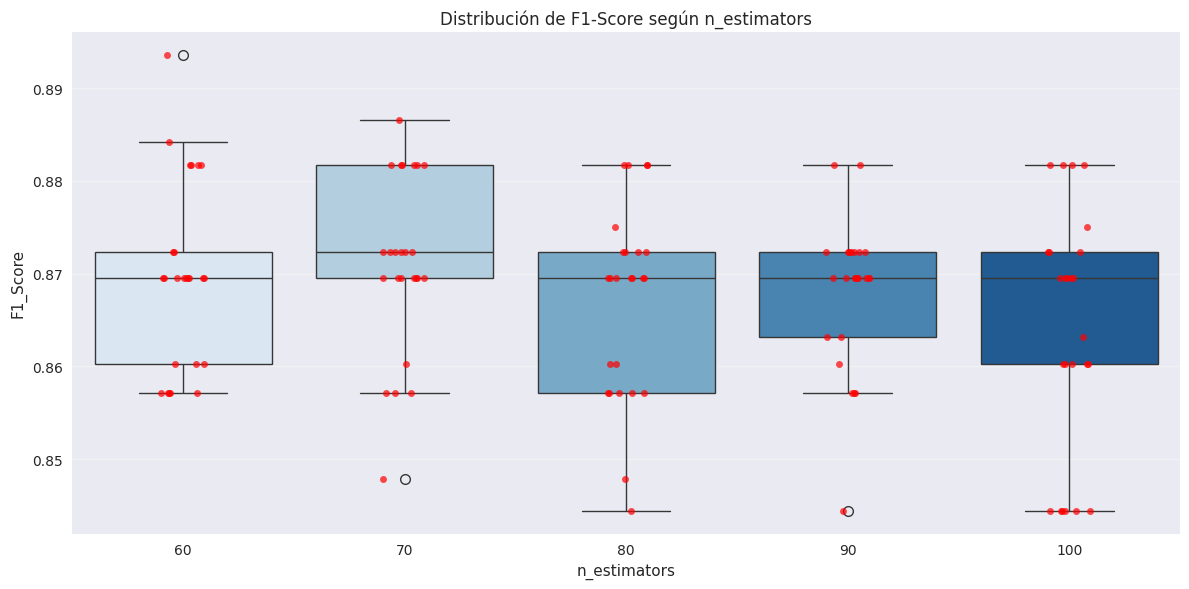

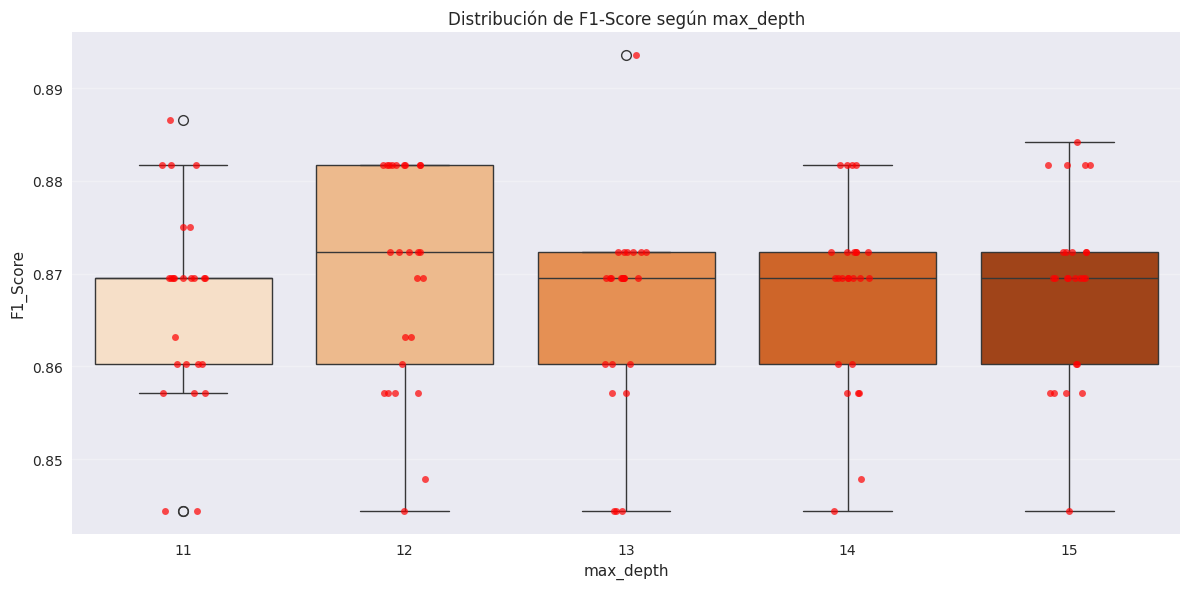

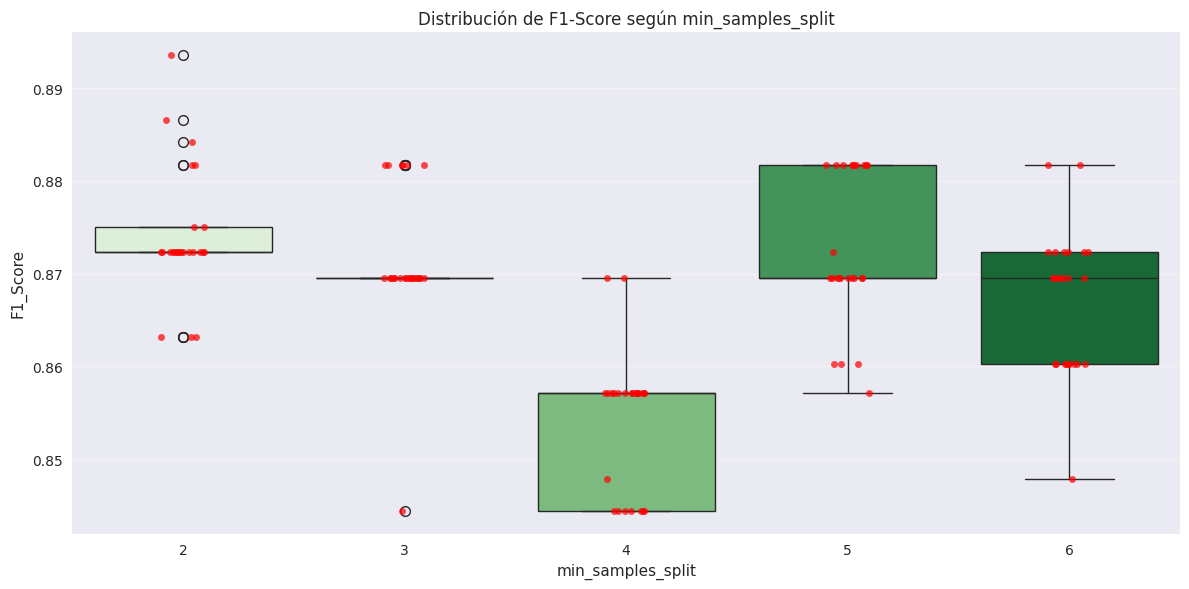


Todos los gráficos y tablas guardados en: /workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint2


In [7]:
# Convertir resultados del tuning a DataFrame
df_tuning = pd.DataFrame(all_tuning_results)

# TABLA COMPARATIVA DE TODAS LAS VARIANTES
print("\n" + "="*100)
print("TABLA COMPARATIVA DE TODAS LAS COMBINACIONES DEL TUNING")
print("="*100)

# Ordenar por F1-Score descendente
df_tuning_sorted = df_tuning.sort_values(by='F1_Score', ascending=False).reset_index(drop=True)

# Mostrar tabla completa y bien formateada
print(df_tuning_sorted[['n_estimators', 'max_depth', 'min_samples_split', 
                       'F1_Score', 'PR_AUC', 'Tiempo(s)']].round(4))

# Guardar tabla completa
df_tuning_sorted.to_csv(f"{OUTPUT_DIR}/tuning.csv", index=False)
print(f"\nTabla completa guardada en: {OUTPUT_DIR}/tuning.csv")

# TABLA TOP 15
print("\n" + "="*80)
print("TOP 15 MEJORES COMBINACIONES")
print("="*80)
top15 = df_tuning_sorted.head(15)
print(top15[['n_estimators', 'max_depth', 'min_samples_split', 
             'F1_Score', 'PR_AUC', 'Tiempo(s)']].round(4))

# GRÁFICOS

# 1. Heatmap
plt.figure(figsize=(16, 9))
pivot = df_tuning.pivot_table(
    values='F1_Score', 
    index='max_depth', 
    columns=['n_estimators', 'min_samples_split'], 
    aggfunc='mean'
)

sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', linewidths=0.5, linecolor='white', 
            cbar_kws={'label': 'F1-Score'})
plt.title('Heatmap de F1-Score según Hiperparámetros', fontsize=14)
plt.xlabel('n_estimators  |  min_samples_split')
plt.ylabel('max_depth')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/tuning_heatmap.png", dpi=100, bbox_inches='tight')
plt.show()

# 2. Distribución por n_estimators
plt.figure(figsize=(12, 6))
sns.boxplot(x='n_estimators', y='F1_Score', data=df_tuning, palette='Blues')
sns.stripplot(x='n_estimators', y='F1_Score', data=df_tuning, color='red', alpha=0.7, size=5)
plt.title('Distribución de F1-Score según n_estimators')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/tuning_n_estimators.png", dpi=100, bbox_inches='tight')
plt.show()

# 3. Distribución por max_depth
plt.figure(figsize=(12, 6))
sns.boxplot(x='max_depth', y='F1_Score', data=df_tuning, palette='Oranges')
sns.stripplot(x='max_depth', y='F1_Score', data=df_tuning, color='red', alpha=0.7, size=5)
plt.title('Distribución de F1-Score según max_depth')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/tuning_max_depth.png", dpi=100, bbox_inches='tight')
plt.show()

# 4. Distribución por min_samples_split
plt.figure(figsize=(12, 6))
sns.boxplot(x='min_samples_split', y='F1_Score', data=df_tuning, palette='Greens')
sns.stripplot(x='min_samples_split', y='F1_Score', data=df_tuning, color='red', alpha=0.7, size=5)
plt.title('Distribución de F1-Score según min_samples_split')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/tuning_min_samples_split.png", dpi=100, bbox_inches='tight')
plt.show()

print(f"\nTodos los gráficos y tablas guardados en: {OUTPUT_DIR}")

## Tabla comparativa

In [8]:
df_comparacion = pd.DataFrame(resultados)

# Reordenar columnas para mejor lectura
df_comparacion = df_comparacion[['Experimento', 'PR_AUC', 'F1_Score', 'Tiempo(s)']]

# Mostrar tabla formateada
print(df_comparacion.round(4))

# Resaltar el mejor modelo
mejor = df_comparacion.loc[df_comparacion['F1_Score'].idxmax()]
print("\n" + "="*60)
print(f"MEJOR MODELO: {mejor['Experimento']}")
print(f"F1-Score: {mejor['F1_Score']:.4f} | PR-AUC: {mejor['PR_AUC']:.4f}")
print("="*60)

# Guardar tabla
df_comparacion.to_csv(f"{OUTPUT_DIR}/metrics_experimentos.csv", index=False)

print(f"\nTabla comparativa guardada en: {OUTPUT_DIR}/metrics_experimentos.csv")

     Experimento  PR_AUC  F1_Score  Tiempo(s)
0       Baseline  0.7182    0.6789       1.50
1  Baseline + FE  0.9792    0.8723       0.89
2    FE + Tuning  0.9831    0.8936       0.53

MEJOR MODELO: FE + Tuning
F1-Score: 0.8936 | PR-AUC: 0.9831

Tabla comparativa guardada en: /workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint2/metrics_experimentos.csv


## Graficos comparativos

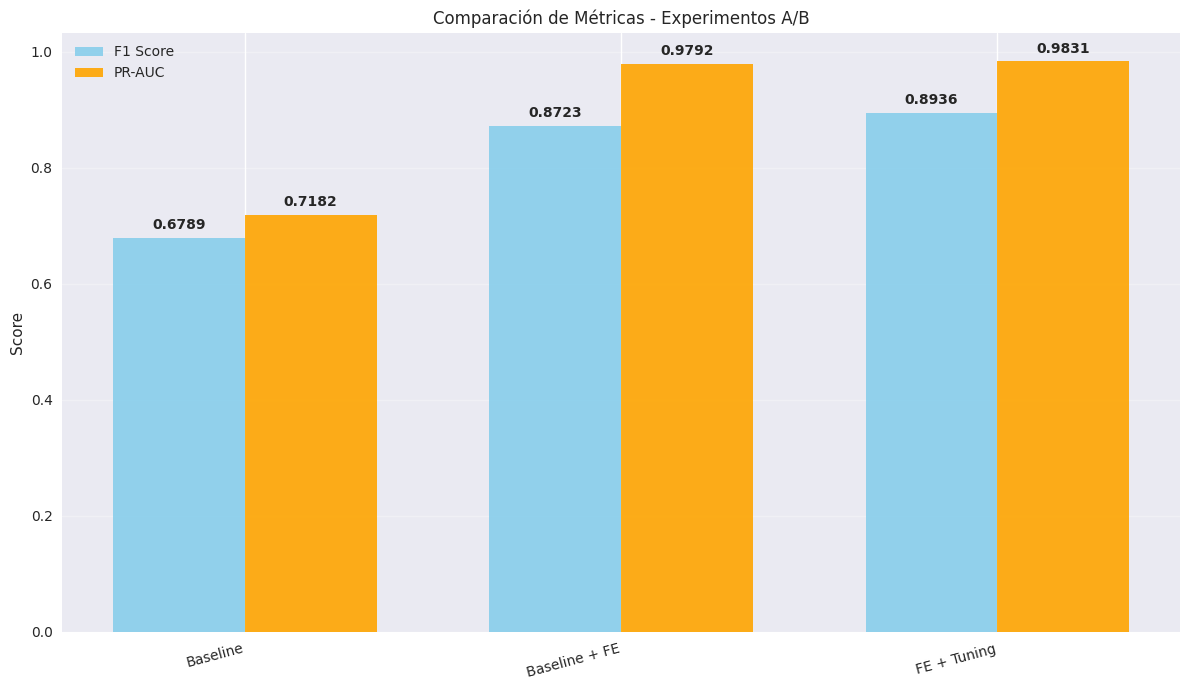

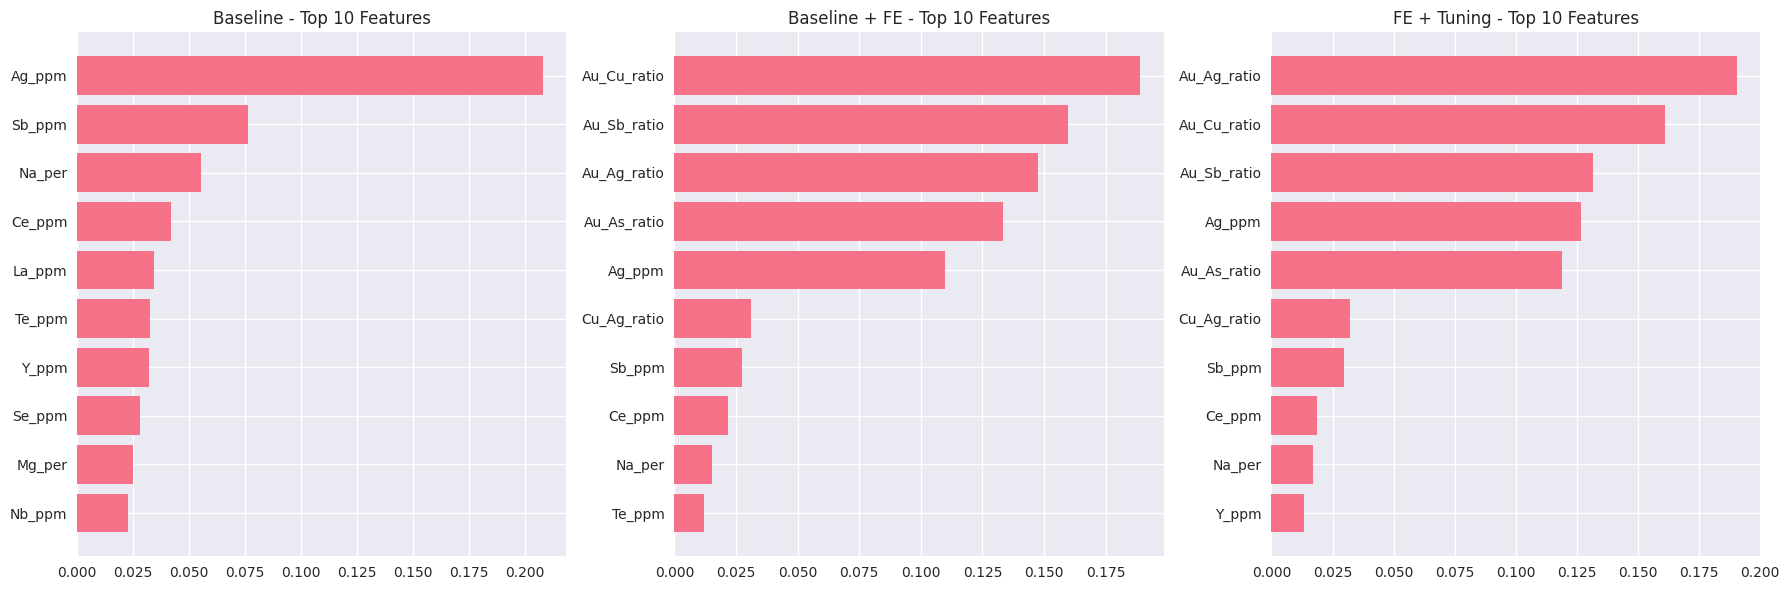

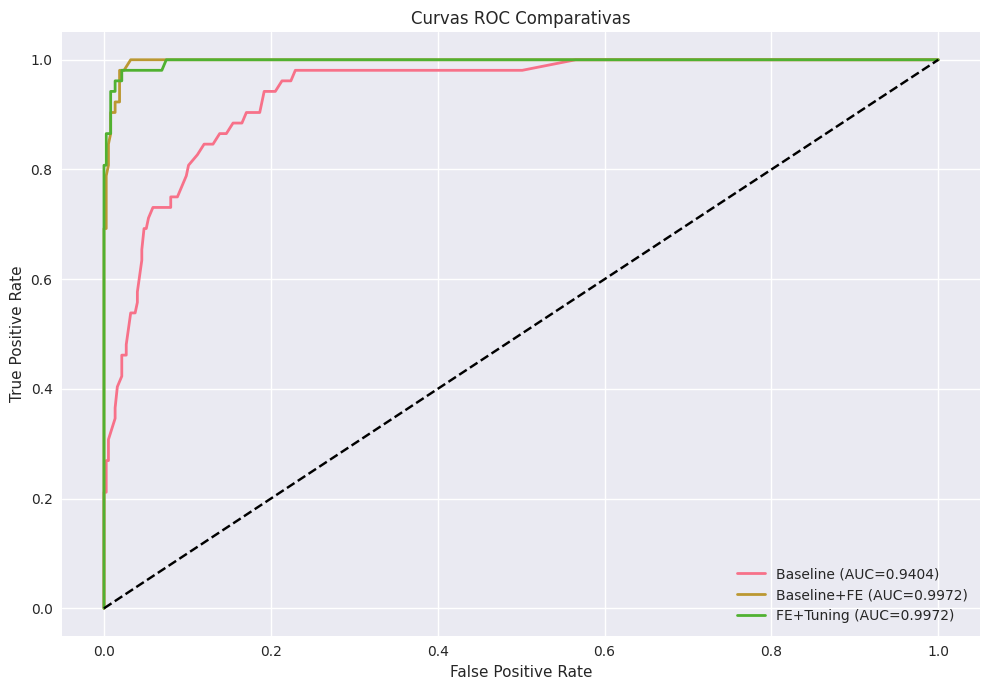

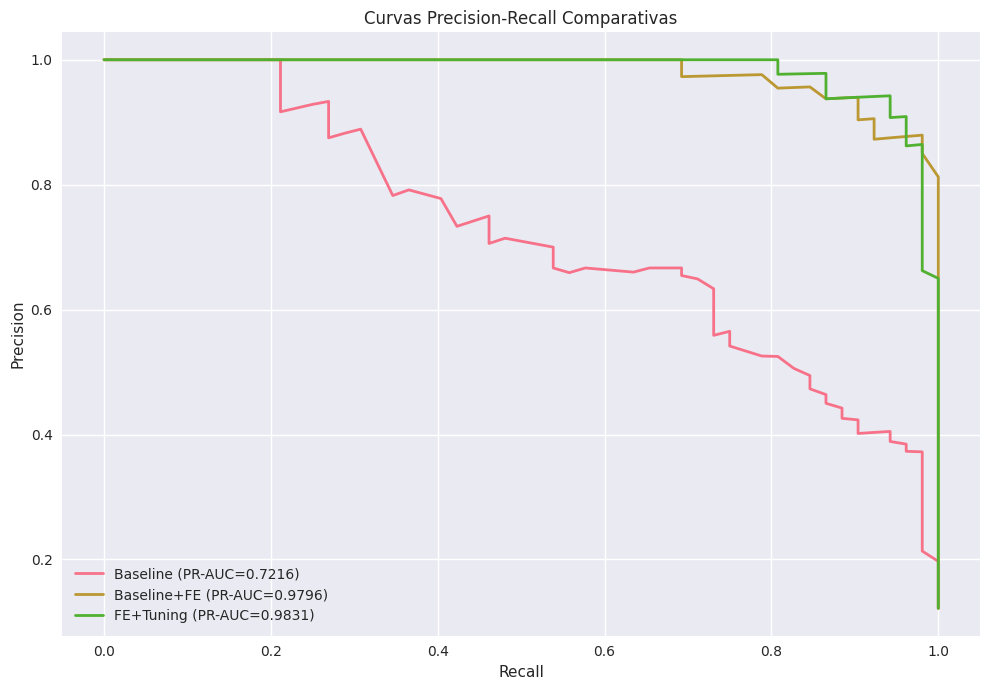

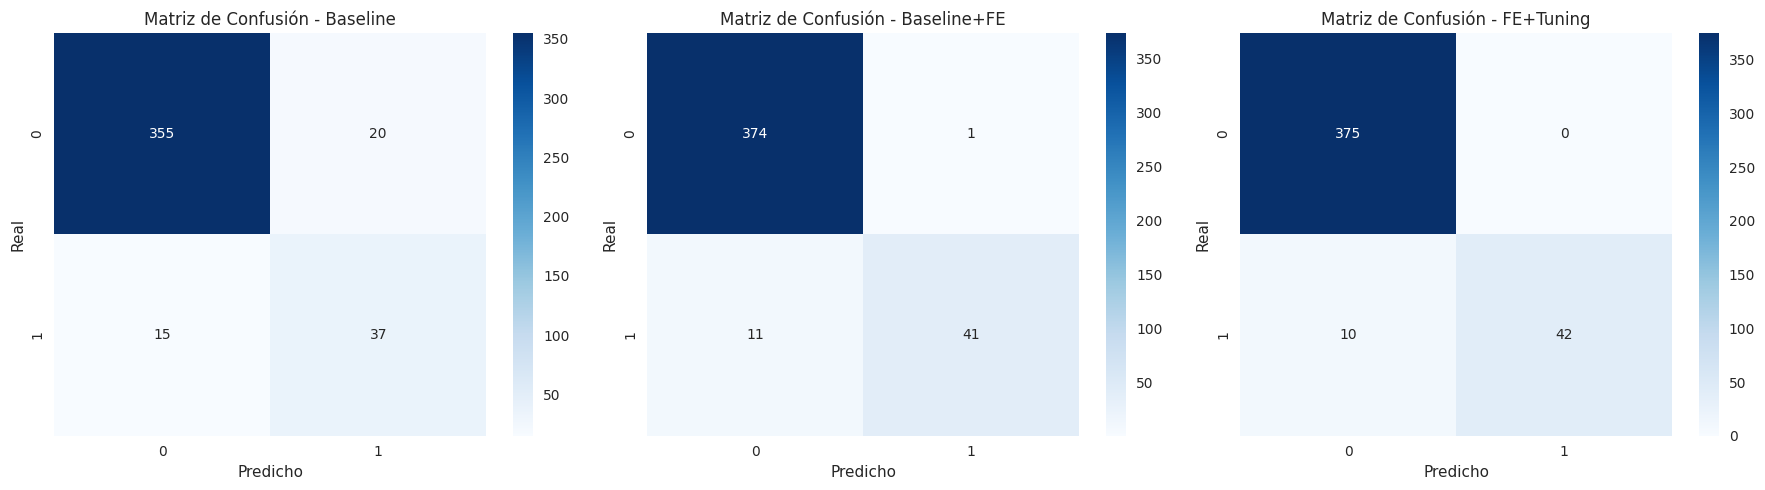


Todos los gráficos han sido guardados correctamente en:
/workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint2


In [9]:
# 1. Comparación de Métricas
df_comp = pd.DataFrame(resultados)
plt.figure(figsize=(12, 7))
x = np.arange(len(df_comp))
width = 0.35

bars1 = plt.bar(x - width/2, df_comp['F1_Score'], width, label='F1 Score', color='skyblue', alpha=0.9)
bars2 = plt.bar(x + width/2, df_comp['PR_AUC'], width, label='PR-AUC', color='orange', alpha=0.9)

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.4f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.4f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks(x, df_comp['Experimento'], rotation=15, ha='right')
plt.ylabel('Score')
plt.title('Comparación de Métricas - Experimentos A/B')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/FE_comparacion.png", dpi=100, bbox_inches='tight')
plt.show()

# 2. Feature Importance Comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Baseline
importances_b = model_base.feature_importances_
indices_b = np.argsort(importances_b)[-10:]
axes[0].barh(range(10), importances_b[indices_b])
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([features_base[i] for i in indices_b])
axes[0].set_title('Baseline - Top 10 Features')

# Baseline + FE
importances_fe = model_fe.feature_importances_
indices_fe = np.argsort(importances_fe)[-10:]
axes[1].barh(range(10), importances_fe[indices_fe])
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([features_fe[i] for i in indices_fe])
axes[1].set_title('Baseline + FE - Top 10 Features')

# FE + Tuning
importances_best = best_model.feature_importances_
indices_best = np.argsort(importances_best)[-10:]
axes[2].barh(range(10), importances_best[indices_best])
axes[2].set_yticks(range(10))
axes[2].set_yticklabels([features_fe[i] for i in indices_best])
axes[2].set_title('FE + Tuning - Top 10 Features')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/FE_Importancia.png", dpi=100, bbox_inches='tight')
plt.show()

# 3. Curvas ROC
plt.figure(figsize=(10, 7))
fpr_b, tpr_b, _ = roc_curve(y_test, y_proba_base)
fpr_fe, tpr_fe, _ = roc_curve(y_test, y_proba_fe)
fpr_best, tpr_best, _ = roc_curve(y_test, y_proba_best)

plt.plot(fpr_b, tpr_b, label=f'Baseline (AUC={auc(fpr_b,tpr_b):.4f})', linewidth=2)
plt.plot(fpr_fe, tpr_fe, label=f'Baseline+FE (AUC={auc(fpr_fe,tpr_fe):.4f})', linewidth=2)
plt.plot(fpr_best, tpr_best, label=f'FE+Tuning (AUC={auc(fpr_best,tpr_best):.4f})', linewidth=2)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC Comparativas')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/FE_curves_roc.png", dpi=100, bbox_inches='tight')
plt.show()

# 4. Curvas Precision-Recall
plt.figure(figsize=(10, 7))
for name, proba, label in zip(['Baseline', 'Baseline+FE', 'FE+Tuning'], 
                             [y_proba_base, y_proba_fe, y_proba_best],
                             ['Baseline', 'Baseline+FE', 'FE+Tuning']):
    precision, recall, _ = precision_recall_curve(y_test, proba)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{label} (PR-AUC={pr_auc:.4f})', linewidth=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curvas Precision-Recall Comparativas')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/FE_curves_precision_recall.png", dpi=100, bbox_inches='tight')
plt.show()

# 5. Matrices de Confusión
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model, name, X_test in zip(axes, 
                                  [model_base, model_fe, best_model],
                                  ['Baseline', 'Baseline+FE', 'FE+Tuning'],
                                  [X_test_base, X_test_fe, X_test_fe]):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Matriz de Confusión - {name}')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/FE_matrices_confusion.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTodos los gráficos han sido guardados correctamente en:\n{OUTPUT_DIR}")

# SHAP, Learning Curves y Calibración

## Importar librerias

In [10]:
import shap
from sklearn.model_selection import LearningCurveDisplay, StratifiedKFold
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
import warnings
warnings.filterwarnings('ignore')

print("Librerías cargadas")

Librerías cargadas


## Seleccion de Features

In [11]:
print("=== ANÁLISIS DE IMPORTANCIA DE FEATURES ===")

# Usamos el mejor modelo (FE + Tuning)
best_model = best_model

# 1. Importancia por Gain (RandomForest)
importancias = pd.Series(best_model.feature_importances_, 
                        index=X_train_fe.columns).sort_values(ascending=False)

print("Top 15 Features más importantes:")
print(importancias.head(15))

# Guardar
importancias.to_csv(f"{OUTPUT_DIR}/feature_importance.csv")

=== ANÁLISIS DE IMPORTANCIA DE FEATURES ===
Top 15 Features más importantes:
Au_Ag_ratio       0.190678
Au_Cu_ratio       0.160924
Au_Sb_ratio       0.131707
Ag_ppm            0.126862
Au_As_ratio       0.118962
Cu_Ag_ratio       0.032067
Sb_ppm            0.029839
Ce_ppm            0.018736
Na_per            0.016905
Y_ppm             0.013304
Al_per            0.012135
Te_ppm            0.010703
pathfinder_sum    0.008038
Se_ppm            0.007070
Ta_ppm            0.006228
dtype: float64


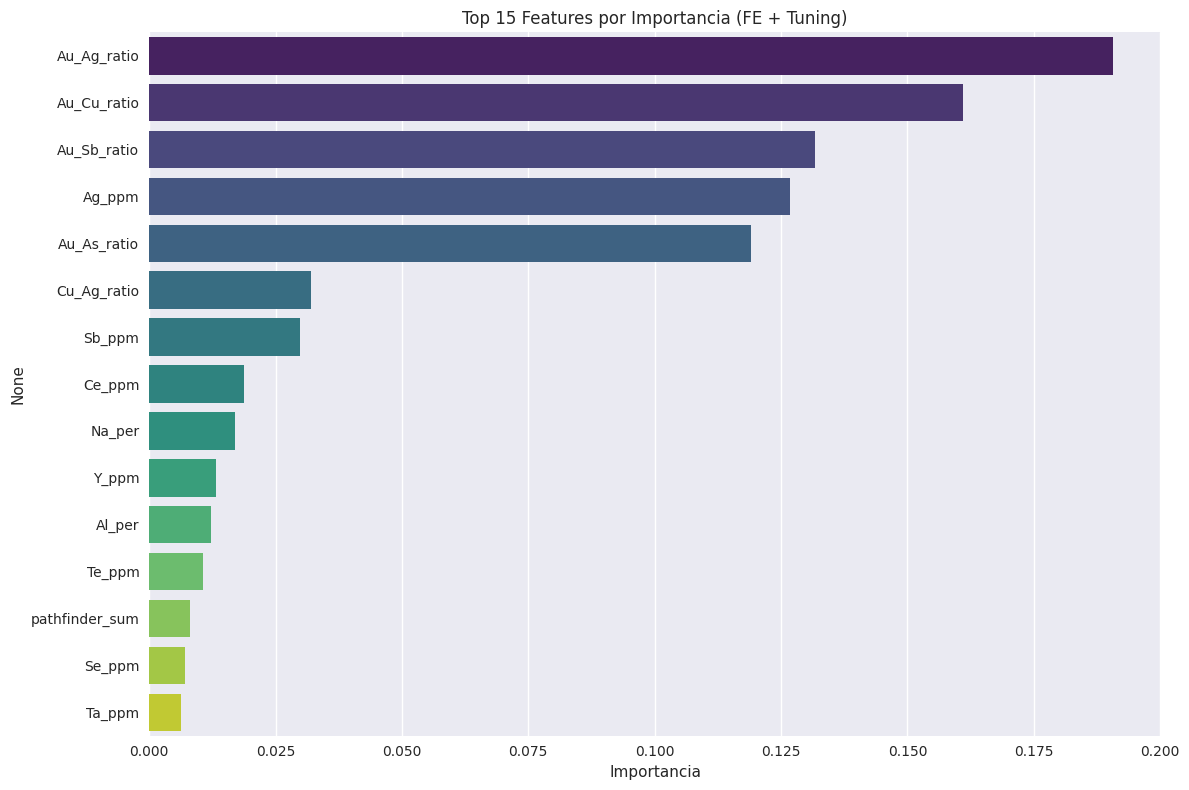

In [12]:
# Visualización
plt.figure(figsize=(12, 8))
sns.barplot(x=importancias.head(15).values, y=importancias.head(15).index, palette='viridis')
plt.title('Top 15 Features por Importancia (FE + Tuning)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_importance_top15.png", dpi=100, bbox_inches='tight')
plt.show()

## Análisis SHAP

Calculando valores SHAP...


Tipo de shap_values: <class 'numpy.ndarray'>
Shape original: (427, 57, 2)


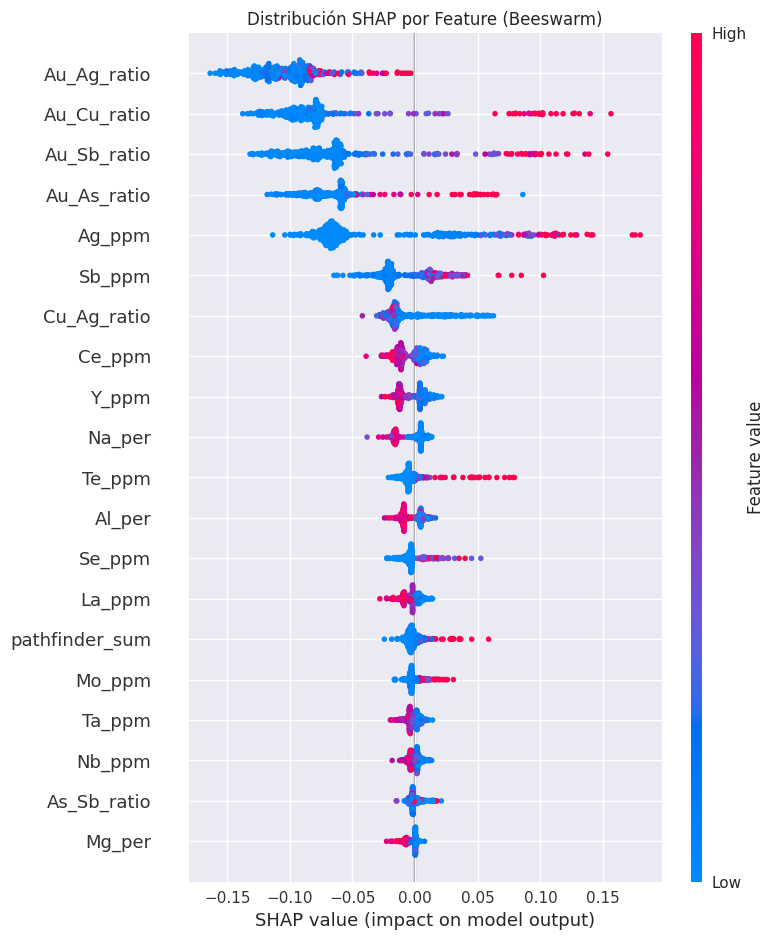

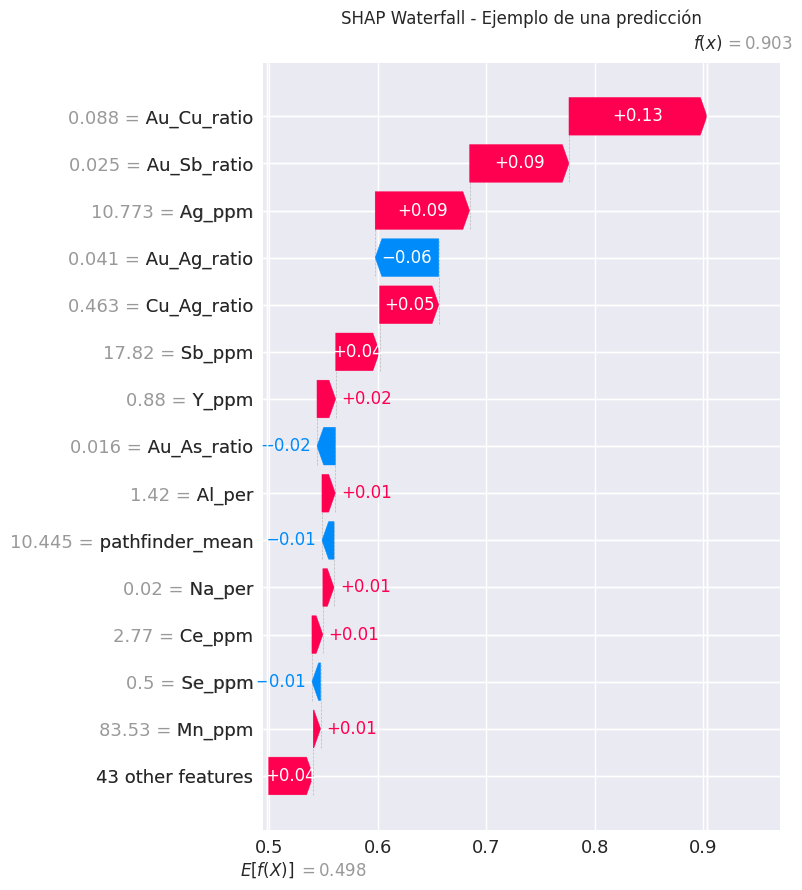

In [13]:
print("Calculando valores SHAP...")

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_fe)

print(f"Tipo de shap_values: {type(shap_values)}")
print(f"Shape original: {np.asarray(shap_values).shape}")

if isinstance(shap_values, list):
    shap_values_to_use = shap_values[1]
elif len(np.asarray(shap_values).shape) == 3:
    shap_values_to_use = shap_values[:, :, 1]
else:
    shap_values_to_use = shap_values

# 2. Summary Plot - Beeswarm
plt.figure(figsize=(14, 10))
shap.summary_plot(shap_values_to_use, X_test_fe, show=False)
plt.title("Distribución SHAP por Feature (Beeswarm)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shap_summary_beeswarm.png", dpi=100, bbox_inches='tight')
plt.show()
plt.close()

# 3. Waterfall
plt.figure(figsize=(12, 8))
explanation = shap.Explanation(
    values=shap_values_to_use[0],
    base_values=explainer.expected_value[1] 
                if hasattr(explainer, 'expected_value') and isinstance(explainer.expected_value, (list, np.ndarray)) 
                else explainer.expected_value,
    data=X_test_fe.iloc[0:1].values[0],
    feature_names=X_test_fe.columns.tolist()
)

shap.plots.waterfall(explanation, max_display=15, show=False)
plt.title("SHAP Waterfall - Ejemplo de una predicción")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shap_waterfall_example.png", dpi=100, bbox_inches='tight')
plt.show()
plt.close()

## Curvas de Aprendizaje

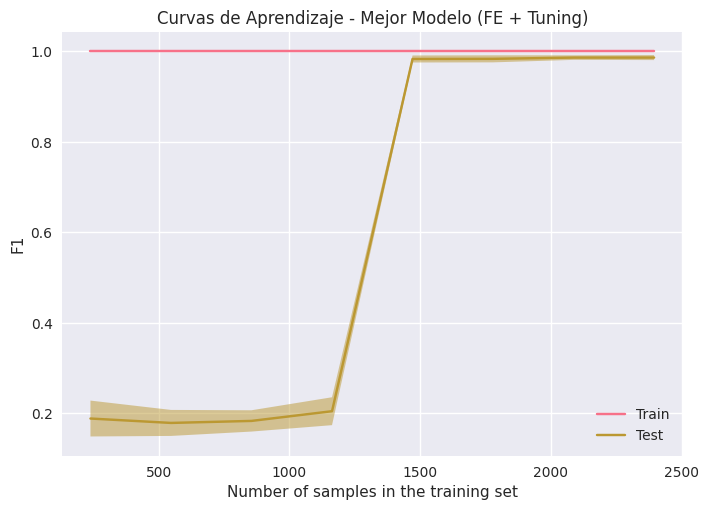

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

LearningCurveDisplay.from_estimator(
    best_model, 
    X_train_fe, 
    y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8),
    score_type='both'
)

plt.title('Curvas de Aprendizaje - Mejor Modelo (FE + Tuning)')
plt.grid(True)
plt.savefig(f"{OUTPUT_DIR}/learning_curves.png", dpi=100, bbox_inches='tight')
plt.show()
plt.close()

## Calibración del Modelo

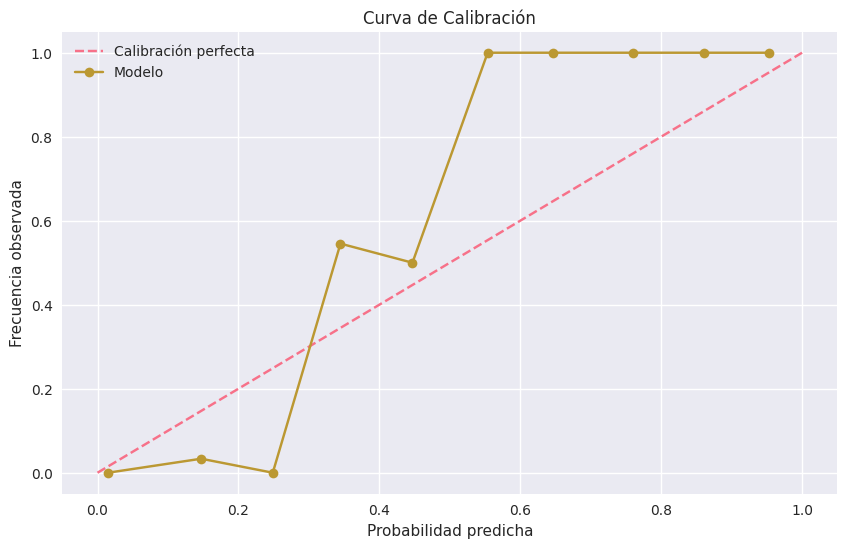

Brier Score: 0.0216 (más bajo = mejor calibrado)


In [15]:
y_prob = best_model.predict_proba(X_test_fe)[:, 1]

# Curva de calibración
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(10, 6))
plt.plot([0, 1], [0, 1], linestyle='--', label='Calibración perfecta')
plt.plot(prob_pred, prob_true, marker='o', label='Modelo')
plt.xlabel('Probabilidad predicha')
plt.ylabel('Frecuencia observada')
plt.title('Curva de Calibración')
plt.legend()
plt.grid(True)
plt.savefig(f"{OUTPUT_DIR}/calibration_curve.png", dpi=100, bbox_inches='tight')
plt.show()
plt.close()

# Brier Score
brier = brier_score_loss(y_test, y_prob)
print(f"Brier Score: {brier:.4f} (más bajo = mejor calibrado)")